<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

#0 - OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



#1 - Importation des librairies et chargement des fichiers

##1.1 - Importation des librairies

In [ ]:
#Importation de la librairie Pandas
import pandas as pd

In [ ]:
#Importation de la librairie plotly express
import plotly.express as px

In [ ]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

##1.2 - Chargements des fichiers

In [ ]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("erp.xlsx")
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel("liaison.xlsx")

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed



#2 - Analyse exploratoire des fichiers

##2.1 - Analyse exploratoire du fichier erp.xlsx

In [ ]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes

df_erp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


In [ ]:
#Afficher les 5 premières lignes de la table
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [ ]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
df_erp['product_id'].duplicated().any()

np.False_

In [ ]:
#Afficher les valeurs distinctes de la colonne stock_status
#À quelle(s) autre(s) colonne(s) sont-elles liées ?

print(df_erp['stock_status'].unique())

# Filter rows where 'stock_quantity' is 0
df_erp.loc[df_erp['stock_quantity']==0]

#item 398 : stock_quantity=0 stock_status=instock -> erreur

['instock' 'outofstock']


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
2,3850,1,20.80,0,outofstock,10.64
8,4043,1,60.00,0,outofstock,29.45
11,4047,1,18.30,0,outofstock,9.93
15,4051,1,7.70,0,outofstock,4.14
16,4052,1,33.70,0,outofstock,18.11
19,4055,0,86.10,0,outofstock,37.88
28,4065,1,19.50,0,outofstock,9.67
42,4079,1,37.00,0,outofstock,19.50
49,4090,0,73.00,0,outofstock,33.79
50,4092,0,47.00,0,outofstock,25.25


In [ ]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"

df_erp["stock_status_2"]=df_erp["stock_quantity"].apply(lambda x: "outofstock" if x==0 else "instock")


In [ ]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

,0
0,True
1,True
2,True
3,True
4,False
5,True
6,True
7,True
8,True
9,True


In [ ]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset

(df_erp["stock_status"] == df_erp["stock_status_2"]).sum()

np.int64(821)

In [ ]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3

df_erp.loc[df_erp['stock_status']!=df_erp['stock_status_2']]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock
449,4973,0,10.0,-10,outofstock,4.96,instock
573,5700,1,44.5,-1,outofstock,22.30,instock


In [ ]:
#Corriger la ou les données incohérentes
df_erp.loc[df_erp['product_id']==4039, 'stock_status'] = 'instock'

df_erp.loc[df_erp['product_id']==4885, 'stock_status'] = 'outofstock'

df_erp.loc[df_erp['product_id']==4973, 'stock_quantity'] = 0

df_erp.loc[df_erp['product_id']==5700, 'stock_quantity'] = 0

#Redéfinir la colonne stock_status_2
df_erp["stock_status_2"]=df_erp["stock_quantity"].apply(lambda x: "outofstock" if x==0 else "instock")


#Vérification en utilisant le même code que plus haut pour afficher les problèmes
(df_erp["stock_status"] == df_erp["stock_status_2"]).sum()

np.int64(825)

###2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx

###2.1.1.1 - Analyse de la variable PRIX

In [ ]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'articles avec un prix non renseigné: {}".format(df_erp["price"].isnull().sum())) #Saisir l'instruction manquante dans la fonction format

#Afficher le prix minimum de la colonne "price"
print("Prix minimum: {}".format(df_erp["price"].min()))

#Afficher le prix maximum de la colonne "price"
print("Prix maximum: {}".format(df_erp["price"].max()))

#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
df_erp.loc[df_erp["price"]<0]
#Supprimer les lignes à fins d'analyse


Nombres d'articles avec un prix non renseigné: 0
Prix minimum: -20.0
Prix maximum: 225.0


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
151,4233,0,-20.0,0,outofstock,10.33,outofstock
469,5017,0,-8.0,0,outofstock,4.34,outofstock
739,6594,0,-9.1,19,instock,4.61,instock


In [ ]:
#Corrections au fichier

df_erp.loc[df_erp['product_id']==4233, 'price'] = 20.0
df_erp.loc[df_erp['product_id']==5017, 'price'] = 8.0
df_erp.loc[df_erp['product_id']==6594, 'price'] = 9.1

df_erp.drop( df_erp[ df_erp['price'] < 0 ].index, inplace=True)

###2.1.1.2 - Analyse de la variable **STOCK**

In [ ]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
print("Nombres d'articles avec un stock non renseigné: {}".format(df_erp["stock_quantity"].isnull().sum()))

#Afficher la quantité minimum de la colonne "stock_quantity"
print("Stock minimum: {}".format(df_erp["stock_quantity"].min()))

#Afficher la quantité maximum de la colonne "stock_quantity"
print("Stock maximum: {}".format(df_erp["stock_quantity"].max()))

#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
print("Stocks inférieurs à 0: {}".format(df_erp.loc[df_erp["stock_quantity"]<0]))



Nombres d'articles avec un stock non renseigné: 0
Stock minimum: 0
Stock maximum: 145
Stocks inférieurs à 0: Empty DataFrame
Columns: [product_id, onsale_web, price, stock_quantity, stock_status, purchase_price, stock_status_2]
Index: []


###2.1.1.3 - Analyse de la variable ONSALE_WEB

In [ ]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
df_erp["onsale_web"].unique()
#df_erp["onsale_web"].value_counts()
#Contient un booléen indiquant si le produit est en vente sur le site WEB

array([1, 0])

In [ ]:
#Quelles sont les colonnes à conserver selon vous?

#Selon moi, toutes les colonnes initiales seront pertinentes pour les diverses analyses

In [ ]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante
#avec la colonne "stock_status".
del df_erp["stock_status_2"]

###2.1.1.4 - Analyse de la variable prix d'achat

In [ ]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price :
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print("Prix d'achat non renseigné: {}".format(df_erp["purchase_price"].isnull().sum()))

#Afficher le prix minimum de la colonne "purchase_price"
print("Prix minimum: {}".format(df_erp["purchase_price"].min()))


#Afficher le prix maximum de la colonne "purchase_price"
print("Prix maximum: {}".format(df_erp["purchase_price"].max()))



Prix d'achat non renseigné: 0
Prix minimum: 2.74
Prix maximum: 137.81


In [ ]:
#Erreurs dans le choix des prix de vente ?

df_erp.loc[df_erp["price"]<df_erp["purchase_price"]]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
210,4355,1,12.65,97,instock,77.48
391,4864,0,8.30,0,outofstock,9.99
724,6324,0,92.00,18,instock,99.00
817,7196,0,31.00,55,instock,31.20


##2.2 - Analyse exploratoire du fichier web.xlsx

In [ ]:
#Dimension du dataset
#Nombre d'observations
#Nombre de caractéristiques

print("Le tableau comporte {} observation(s) ou article(s)".format(df_web.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_web.shape[1]))

Le tableau comporte 1513 observation(s) ou article(s)
Le tableau comporte 29 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes

df_web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

In [ ]:
#Selon vous, quelles sont les colonnes à conserver ?

#A fins d'analyses, conserver les colonnes sku,total_sales,name

In [ ]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
df_web = df_web.drop('tax_class', axis=1)
df_web = df_web.drop('post_content', axis=1)
df_web = df_web.drop('post_password', axis=1)
df_web = df_web.drop('post_content_filtered', axis=1)

df_web = df_web.drop('virtual', axis=1)
df_web = df_web.drop('downloadable', axis=1)
df_web = df_web.drop('rating_count', axis=1)
df_web = df_web.drop('average_rating', axis=1)

df_web = df_web.drop('post_parent', axis=1)
df_web = df_web.drop('menu_order', axis=1)
df_web = df_web.drop('comment_count', axis=1)

df_web = df_web.drop('post_author', axis=1)
df_web = df_web.drop('post_date', axis=1)
df_web = df_web.drop('post_date_gmt', axis=1)
df_web = df_web.drop('post_modified', axis=1)
df_web = df_web.drop('post_modified_gmt', axis=1)

df_web.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sku             1428 non-null   object 
 1   total_sales     1430 non-null   float64
 2   tax_status      716 non-null    object 
 3   product_type    1429 non-null   object 
 4   post_title      1430 non-null   object 
 5   post_excerpt    716 non-null    object 
 6   post_status     1430 non-null   object 
 7   comment_status  1430 non-null   object 
 8   ping_status     1430 non-null   object 
 9   post_name       1430 non-null   object 
 10  guid            1430 non-null   object 
 11  post_type       1430 non-null   object 
 12  post_mime_type  714 non-null    object 
dtypes: float64(1), object(12)
memory usage: 153.8+ KB


In [ ]:
#Visualisation des valeurs de la colonne sku
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?

df_web["sku"].unique()

array([11862, 16057, 14692, 16295, 15328, 15471, 16515, 16246, nan, 13572,
       16513, 16585, 16269, 15526, 12869, 15575, 11586, 14338, 15425,
       16560, 15361, 13809, 11587, 15022, 14323, 16342, 16029, 15475,
       13754, 14680, 15875, 9636, 13849, 13662, 16564, 13557, 15429,
       14712, 15032, 15481, 15448, 16580, 15441, 804, 15300, 13958, 16071,
       15678, 13895, 15711, 12882, 16053, 13766, 16247, 12640, 15292,
       15476, 15670, 16189, 16038, 14864, 16044, 15324, 15531, 15953,
       15413, 15733, 14366, 15895, 15892, 16472, 15185, 16010, 15793,
       15849, 12315, 15741, 15934, 15148, 15781, 15659, 15106, 15490,
       14507, 14149, 16307, 13736, 14090, 16037, 15758, 14661, 12587,
       15337, 15489, 15201, 16305, 16131, 13435, 15747, 12203, 14509,
       14768, 16262, 14561, 16505, 15717, 16129, 13460, 15871, 15940,
       11602, 13127, 13520, 15480, 13032, 15436, 15269, 15910, 19821,
       16263, 15138, 15146, 15126, 15482, 16186, 13905, 16540, 15856,
       1567

In [ ]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les

df_web.loc[(df_web['sku']=='bon-cadeau-25-euros') | (df_web['sku']=='13127-1')]

,sku,total_sales,tax_status,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,guid,post_type,post_mime_type
272,13127-1,4.0,taxable,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,"Nez gracieux, très élégant avec une touche flo...",publish,closed,closed,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,https://www.bottle-neck.fr/?post_type=product&...,product,NaN
842,bon-cadeau-25-euros,7.0,NaN,Autre,Bon cadeau de 25€,NaN,publish,closed,closed,bon-cadeau-de-25-euros,https://www.bottle-neck.fr/wp-content/uploads/...,attachment,image/jpeg
1117,13127-1,4.0,NaN,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,NaN,publish,closed,closed,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,https://www.bottle-neck.fr/wp-content/uploads/...,attachment,image/jpeg
1387,bon-cadeau-25-euros,7.0,taxable,NaN,Bon cadeau de 25€,"<span style=""color: #a85253;""><strong>Parlons ...",publish,closed,closed,bon-cadeau-de-25-euros,https://www.bottle-neck.fr/?post_type=product&...,product,NaN


In [ ]:
#Identifier les lignes sans code article

df_web.loc[df_web['sku'].isnull()].info()

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sku             0 non-null      object 
 1   total_sales     2 non-null      float64
 2   tax_status      2 non-null      object 
 3   product_type    2 non-null      object 
 4   post_title      2 non-null      object 
 5   post_excerpt    2 non-null      object 
 6   post_status     2 non-null      object 
 7   comment_status  2 non-null      object 
 8   ping_status     2 non-null      object 
 9   post_name       2 non-null      object 
 10  guid            2 non-null      object 
 11  post_type       2 non-null      object 
 12  post_mime_type  0 non-null      object 
dtypes: float64(1), object(12)
memory usage: 9.3+ KB


In [ ]:
df_web.loc[df_web['sku'].isnull()]

,sku,total_sales,tax_status,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,guid,post_type,post_mime_type
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre

#Supprimer les NaN
#Supprimer les bons cadeaux, supprimer l'autre erreur de codification'

In [ ]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
df_web['sku'].duplicated().any()

#len(df_web['sku'].unique())

np.True_

In [ ]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article

#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
df_web.loc[df_web['sku'].isnull()].info()

#3 - Que constatez-vous?
#85 entrées sans code article, 2 avec quelques infos (celles avec le nombre de ventes négatif), 83 totalement vides

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sku             0 non-null      object 
 1   total_sales     2 non-null      float64
 2   tax_status      2 non-null      object 
 3   product_type    2 non-null      object 
 4   post_title      2 non-null      object 
 5   post_excerpt    2 non-null      object 
 6   post_status     2 non-null      object 
 7   comment_status  2 non-null      object 
 8   ping_status     2 non-null      object 
 9   post_name       2 non-null      object 
 10  guid            2 non-null      object 
 11  post_type       2 non-null      object 
 12  post_mime_type  0 non-null      object 
dtypes: float64(1), object(12)
memory usage: 9.3+ KB


In [ ]:
#Corrections au fichier web

#Supprimer les sku NaN
df_web = df_web.dropna(subset=['sku'])

#Compte des doublons
len(df_web['sku'].unique())

#Supprimer ce qui n'est pas un article
df_web.drop(df_web[ df_web['post_type']!='product'].index, inplace=True)

#Supprimer les sku étranges
df_web.drop(df_web[ df_web['sku']=='bon-cadeau-25-euros'].index, inplace=True)
df_web.drop(df_web[ df_web['sku']=='13127-1'].index, inplace=True)

#Supprimer les sku doublons
df_web.drop_duplicates(subset=['sku'], inplace=True)
df_web.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 2 to 1509
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sku             712 non-null    object 
 1   total_sales     712 non-null    float64
 2   tax_status      712 non-null    object 
 3   product_type    712 non-null    object 
 4   post_title      712 non-null    object 
 5   post_excerpt    712 non-null    object 
 6   post_status     712 non-null    object 
 7   comment_status  712 non-null    object 
 8   ping_status     712 non-null    object 
 9   post_name       712 non-null    object 
 10  guid            712 non-null    object 
 11  post_type       712 non-null    object 
 12  post_mime_type  0 non-null      object 
dtypes: float64(1), object(12)
memory usage: 77.9+ KB


##2.3 - Analyse exploratoire du fichier liaison.xlsx

In [ ]:
#Dimension du dataset
#Nombre d'observations
#Nombre de caractéristiques

print("Le tableau comporte {} observation(s) ou article(s)".format(df_liaison.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_liaison.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 2 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes

df_liaison.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [ ]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?

df_liaison['product_id'].duplicated().any()

np.False_

In [ ]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?

df_liaison['id_web'].duplicated().any()

np.True_

In [ ]:
#Avons-nous des articles sans correspondance?

df_liaison.info()

# (825-734=) 91 id_web sans correspondance

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [ ]:
df_liaison = df_liaison.dropna(subset=['id_web'])
df_liaison.info()

<class 'pandas.core.frame.DataFrame'>
Index: 734 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  734 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 17.2+ KB


In [ ]:
#Vérification de l'unicité de id_web

df_liaison['id_web'].duplicated().any()

np.False_

#3 - Jonction des fichiers

##3.1 - Jonction du fichier df_erp et df_liaison

In [ ]:
#Fusion des fichiers df_erp et df_liaison

df_erp_liaison = pd.merge(df_erp, df_liaison, on='product_id', how='left')

In [ ]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?

df_erp_liaison.info()

# (822-734=) 88 id_web null

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
 6   id_web          734 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 45.2+ KB


In [ ]:
#Correction fichier df_erp_liaison

df_erp_liaison = df_erp_liaison.dropna(subset=['product_id'])
df_erp_liaison = df_erp_liaison.dropna(subset=['id_web'])

##3.2 - Jonction du fichier df_merge et df_web

In [ ]:
#Fusionner les datasets df_merge et df_web
df_final = pd.merge(df_erp_liaison, df_web, left_on='id_web', right_on='sku', how='outer',indicator=True)

display(df_final['_merge'].loc[df_final['_merge'] != 'both'])


,_merge
81,left_only
127,left_only
139,left_only
180,left_only
185,left_only
186,left_only
212,left_only
218,left_only
224,left_only
227,left_only


In [ ]:
#Avons-nous des lignes sans correspondance?

df_final.info()

# (734-712=) 22 sku null

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   product_id      734 non-null    int64   
 1   onsale_web      734 non-null    int64   
 2   price           734 non-null    float64 
 3   stock_quantity  734 non-null    int64   
 4   stock_status    734 non-null    object  
 5   purchase_price  734 non-null    float64 
 6   id_web          734 non-null    object  
 7   sku             712 non-null    object  
 8   total_sales     712 non-null    float64 
 9   tax_status      712 non-null    object  
 10  product_type    712 non-null    object  
 11  post_title      712 non-null    object  
 12  post_excerpt    712 non-null    object  
 13  post_status     712 non-null    object  
 14  comment_status  712 non-null    object  
 15  ping_status     712 non-null    object  
 16  post_name       712 non-null    object  
 17  guid            

In [ ]:
#Correction df_final

df_final = df_final.dropna(subset=['sku'])

df_final.drop('tax_status', axis=1, inplace=True)
df_final.drop('post_excerpt', axis=1, inplace=True)
df_final.drop('post_status', axis=1, inplace=True)
df_final.drop('comment_status', axis=1, inplace=True)
df_final.drop('ping_status', axis=1, inplace=True)
df_final.drop('post_name', axis=1, inplace=True)
df_final.drop('guid', axis=1, inplace=True)
df_final.drop('post_mime_type', axis=1, inplace=True)



#4 - Analyse univariée des prix

##4.1 - Exploration par la visualisation de données

<Axes: >

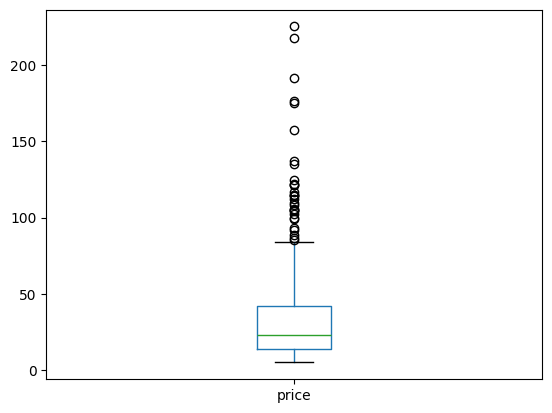

In [ ]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
df_final.boxplot(column =['price'], grid = False)

In [ ]:
#Autre méthode avec plotly express

fig = px.box(df_final, y="price",title="Répartition des prix")
fig.update_layout(yaxis_title="Prix")
fig.show()

##4.2 - Exploration par l'utilisation de méthodes statistiques


###4.2.1 - Identification par le Z-index

In [ ]:
#Calculer la moyenne du prix
prix_moyen=round(df_final["price"].mean(),2)
print("Prix moyen: {}".format(prix_moyen))

#Calculer l'écart-type du prix
prix_ecart_type=round(df_final["price"].std(),2)
print("Ecart-type: {}".format(prix_ecart_type))

#Calculer le Z-score
df_final['z_scores'] = (df_final["price"] - prix_moyen) / prix_ecart_type
print("Z-scores: {}".format(df_final['z_scores']))


Prix moyen: 32.31
Ecart-type: 27.62
Z-scores: 0     -0.858436
1      0.314627
2      0.242216
3      0.998914
4     -0.355177
5      1.610789
6      1.089428
7      1.089428
8      0.263939
9      0.727371
10     0.940985
11     0.745474
12     0.727371
13    -0.101738
14     0.187907
15     0.966329
16     0.604272
17     0.640478
18     0.640478
19     0.727371
20    -0.463794
21     1.093049
22     2.758508
23     2.595583
24     5.202390
25    -0.735337
26     1.835264
27    -0.652064
28     0.988052
29    -0.213975
30     0.358074
31     1.328385
32     0.604272
33     4.514482
34    -0.612238
35    -0.373280
36    -0.796886
37     0.988052
38     0.242216
39     1.074946
40    -0.239319
41     0.133599
42     1.274077
43     0.423244
44     0.387038
45     0.966329
46     0.622375
47    -0.695510
48    -0.300869
49     0.622375
50     0.622375
51     0.622375
52    -0.174149
53     2.414555
54     2.631789
55     0.749095
56     2.030775
57     0.868573
58    -0.105358
59     0.3

In [ ]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
print(3*prix_ecart_type+prix_moyen)

115.17


###4.2.2 - Identification par l'intervalle interquartile

In [ ]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
copie_travail = df_final[['product_id','price']].describe()
print(copie_travail)

        product_id       price
count   712.000000  712.000000
mean   5029.557584   32.312430
std     787.242401   27.620894
min    3847.000000    5.200000
25%    4279.250000   14.037500
50%    4794.500000   23.400000
75%    5709.500000   42.025000
max    7338.000000  225.000000


In [ ]:
#Définir un seuil pour les articles "outliers" en prix
seuil_outliers_calcul=df_final["price"].quantile(0.75)+1.5*(df_final["price"].quantile(0.75)-df_final["price"].quantile(0.25))
print("Seuil outliers:",seuil_outliers_calcul)

#D'après le boxplot plotly, le seuil pour les outliers est à 83.7€
seuil_outliers_boxplot=83.7

Seuil outliers: 84.00625


In [ ]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"

print("Nombres d'articles outliers (calcul) :",df_final.loc[df_final["price"]>seuil_outliers_calcul].shape[0])
print("Proportion des articles outliers (calcul) :",round(df_final.loc[df_final["price"]>seuil_outliers_calcul].shape[0]/df_final.shape[0]*100,2),"%")

print("Nombres d'articles outliers (boxplot) :",df_final.loc[df_final["price"]>seuil_outliers_boxplot].shape[0])
print("Proportion des articles outliers (boxplot) :",round(df_final.loc[df_final["price"]>seuil_outliers_boxplot].shape[0]/df_final.shape[0]*100,2),"%")


Nombres d'articles outliers (calcul) : 31
Proportion des articles outliers (calcul) : 4.35 %
Nombres d'articles outliers (boxplot) : 31
Proportion des articles outliers (boxplot) : 4.35 %


In [ ]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?

#Moins de 5% d'articles, soit une faible minorité d'articles
#Vérifions si ces prix sont des erreurs ou des outliers valides

df_final.loc[df_final["price"]>seuil_outliers_calcul].sort_values(by="price",ascending=False)


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,product_type,post_title,post_type,_merge,z_scores
567,4352,1,225.0,0,outofstock,137.81,15940,15940,11.0,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,product,both,6.976466
204,5001,1,217.5,18,instock,116.87,14581,14581,2.0,Vin,David Duband Charmes-Chambertin Grand Cru 2014,product,both,6.704924
269,5892,1,191.3,98,instock,116.06,14983,14983,6.0,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,product,both,5.756336
24,4402,1,176.0,11,instock,78.25,3510,3510,3.0,Cognac,Cognac Frapin VIP XO,product,both,5.202390
313,5767,1,175.0,12,instock,90.42,15185,15185,4.0,Vin,Camille Giroud Clos de Vougeot 2016,product,both,5.166184
33,4406,1,157.0,12,instock,69.08,7819,7819,4.0,Cognac,Cognac Frapin Château de Fontpinot 1989 20 Ans...,product,both,4.514482
171,4904,1,137.0,9,instock,67.95,14220,14220,3.0,Vin,Domaine Des Croix Corton Charlemagne Grand Cru...,product,both,3.790369
257,6126,1,135.0,138,instock,80.33,14923,14923,5.0,Champagne,Champagne Gosset Célébris Vintage 2007,product,both,3.717958
256,5612,1,124.8,19,instock,66.41,14915,14915,1.0,Vin,Domaine Weinbach Gewurztraminer Grand Cru Furs...,product,both,3.348660
235,5917,1,122.0,12,instock,54.24,14775,14775,3.0,Whisky,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,product,both,3.247285


#5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée

##5.1 - Analyse des ventes en CA

In [ ]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article

df_final["ca_par_article"]=df_final["price"]*df_final["total_sales"]

#Calculer la somme de la colonne "ca_par_article"
ca_total=round(df_final["ca_par_article"].sum())

#Calcul du CA total du site WEB
print("CA Total Site Web :",ca_total)


CA Total Site Web : 143286


In [ ]:
################################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_final.sort_values(['ca_par_article'],ascending=False, inplace=True)

#Réinitialiser l'index du dataset par un reset_index
df_final.reset_index()

#Afficher les 20 premiers articles en CA
df_final.head(20)

# Convertir product_id en string pour corriger l'affichage
df_final['product_id'] = df_final['product_id'].astype(str)


#Graphique en barre des 20 premiers articles avec plotly express
fig1 = px.bar(df_final.head(20), x='post_title', y='ca_par_article', title='Top 20 Articles par CA')
fig1.update_layout(
    xaxis_title="Nom du Produit",
    yaxis_title="CA généré",
)
fig1.show()

In [ ]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_final['part_CA']=df_final['ca_par_article']/ca_total

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_final['part_CA_cumul']=df_final['part_CA'].cumsum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
print("80% du CA :",df_final.loc[df_final['part_CA_cumul']<=0.8].shape[0],"articles")

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
print("Proportion :",round(df_final.loc[df_final['part_CA_cumul']<=0.8].shape[0]/df_final.shape[0]*100,2),"%")

80% du CA : 432 articles
Proportion : 60.67 %


##Etape 5.2 - Analyse des ventes en quantité

In [ ]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_final.sort_values(['total_sales'],ascending=False, inplace=True)

#Réinitialiser l'index du dataset par un reset_index
df_final.reset_index()

#Afficher les 20 premiers articles en quantité
df_final.head(20)

#Graphique en barre des 20 premiers articles avec plotly express
fig2 = px.bar(df_final.head(20), x='post_title', y='total_sales', title='Top 20 Articles par quantités vendues')
fig2.update_layout(
    xaxis_title="Nom du Produit",
    yaxis_title="Total des ventes",
)
fig2.show()


In [ ]:
############################################
# Calculer le 20 / 80 en quantités vendues #
############################################

#Afficher le volume des ventes
print("Volume des ventes:",df_final['total_sales'].sum())

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_final['part_sales']=df_final['total_sales']/df_final['total_sales'].sum()

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_final['part_sales_cumul']=df_final['part_sales'].cumsum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
print("80% du volume de ventes :",df_final.loc[df_final['part_sales_cumul']<=0.8].shape[0],"articles")

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
print("Proportion :",round(df_final.loc[df_final['part_sales_cumul']<=0.8].shape[0]/df_final.shape[0]*100,2),"%")


Volume des ventes: 5740.0
80% du volume de ventes : 431 articles
Proportion : 60.53 %


##5.3 - Analyse des stocks

In [ ]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Import de nump
import numpy as np

#Création de la colonne Rotation de stock
df_final['nombre_mois_stock']=df_final['stock_quantity']/df_final['total_sales']

#Remplacement des "inf" par 0
df_final['nombre_mois_stock'].replace([np.inf], 0, inplace=True)

#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df_final.sort_values(['nombre_mois_stock'],ascending=False, inplace=True)

#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
fig3 = px.bar(df_final.head(20), x='post_title', y='nombre_mois_stock', title='Flop 20 Articles avec le plus de mois de stock')
fig3.update_layout(
    xaxis_title="Nom du Produit",
    yaxis_title="Nombre de mois de stock",
)
fig3.show()

/tmp/ipython-input-2203008507.py:12: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [ ]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_final['valorisation_stock_euros']=df_final['stock_quantity']*df_final['purchase_price']

#Calculer la somme de la colonne "Valorisation_stock_euros"
print("Valorisation totale des stocks :",round(df_final['valorisation_stock_euros'].sum()),"€")

Valorisation totale des stocks : 276859 €


In [ ]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
print("Nombre de produits en stock :",df_final['stock_quantity'].sum())

Nombre de produits en stock : 16711


##5.4 - Analyse du taux de marge

In [ ]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT
#Taux de TVA pour l'alcool : 20%
df_final['prix_ht']=df_final['price']/(1+0.2)

#Création de la colonne Taux de marge
df_final['taux_marge']=round((df_final['prix_ht']-df_final['purchase_price'])/df_final['purchase_price'],2)

#Afficher le prix minimum de la colonne "taux_marge"
print("Taux de marge minimum :",df_final['taux_marge'].min())

#Afficher le prix maximum de la colonne "taux_marge"
print("Taux de marge maximum :",df_final['taux_marge'].max())

Taux de marge minimum : -0.86
Taux de marge maximum : 0.91


In [ ]:
#Affichage de la ligne avec un taux de marge inférieur à 0

df_final.loc[df_final['taux_marge']<0]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,product_type,post_title,post_type,_merge,z_scores,ca_par_article,part_CA,part_CA_cumul,part_sales,part_sales_cumul,nombre_mois_stock,valorisation_stock_euros,prix_ht,taux_marge
79,4355,1,12.65,97,instock,77.48,12589,12589,0.0,Champagne,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,product,both,-0.711803,0.0,0.0,0.999999,0.0,1.0,0.0,7515.56,10.541667,-0.86


In [ ]:
#Création d'un dataframe avec les taux positifs
df_taux_positifs=df_final.loc[df_final['taux_marge']>0]

#Afficher le prix minimum de la colonne "taux_marge"
print("Taux de marge minimum :",df_taux_positifs['taux_marge'].min())

#Afficher le prix maximum de la colonne "taux_marge"
print("Taux de marge maximum :",df_taux_positifs['taux_marge'].max())


Taux de marge minimum : 0.29
Taux de marge maximum : 0.91


In [ ]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
df_taux_moyen=df_taux_positifs.groupby('product_type')['taux_marge'].mean()

#Affichage dans un graphique du taux de marge par type de produit
fig4=px.bar(df_taux_moyen, x=df_taux_moyen.index, y=df_taux_moyen.values,title='Taux de marge par type de produit')
fig4.update_layout(
    xaxis_title="Type de produit",
    yaxis_title="Taux de marge moyen",
)
fig4.show()


##5.5 - Analyse des corrélations entre les variables stock, sales et price


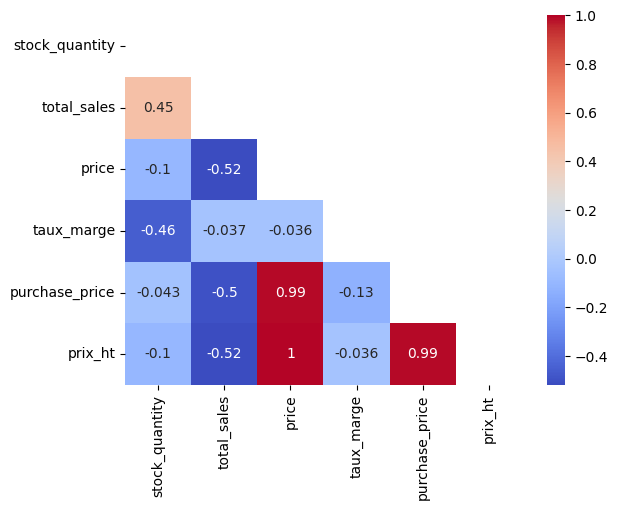

In [ ]:
############################
# Analyse des corrélations #
############################

#Importation de Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

#Création d'une heatmap de corrélation avec les variables stock, sales et price
#On peut également créer un mask pour n'afficher qu'une demi heatmap
matrice_heatmap=df_taux_positifs[['stock_quantity','total_sales','price','taux_marge','purchase_price','prix_ht']].corr()
mask = np.triu(np.ones_like(matrice_heatmap, dtype=bool))
sns.heatmap(matrice_heatmap, annot=True, cmap='coolwarm',mask=mask)
plt.show()

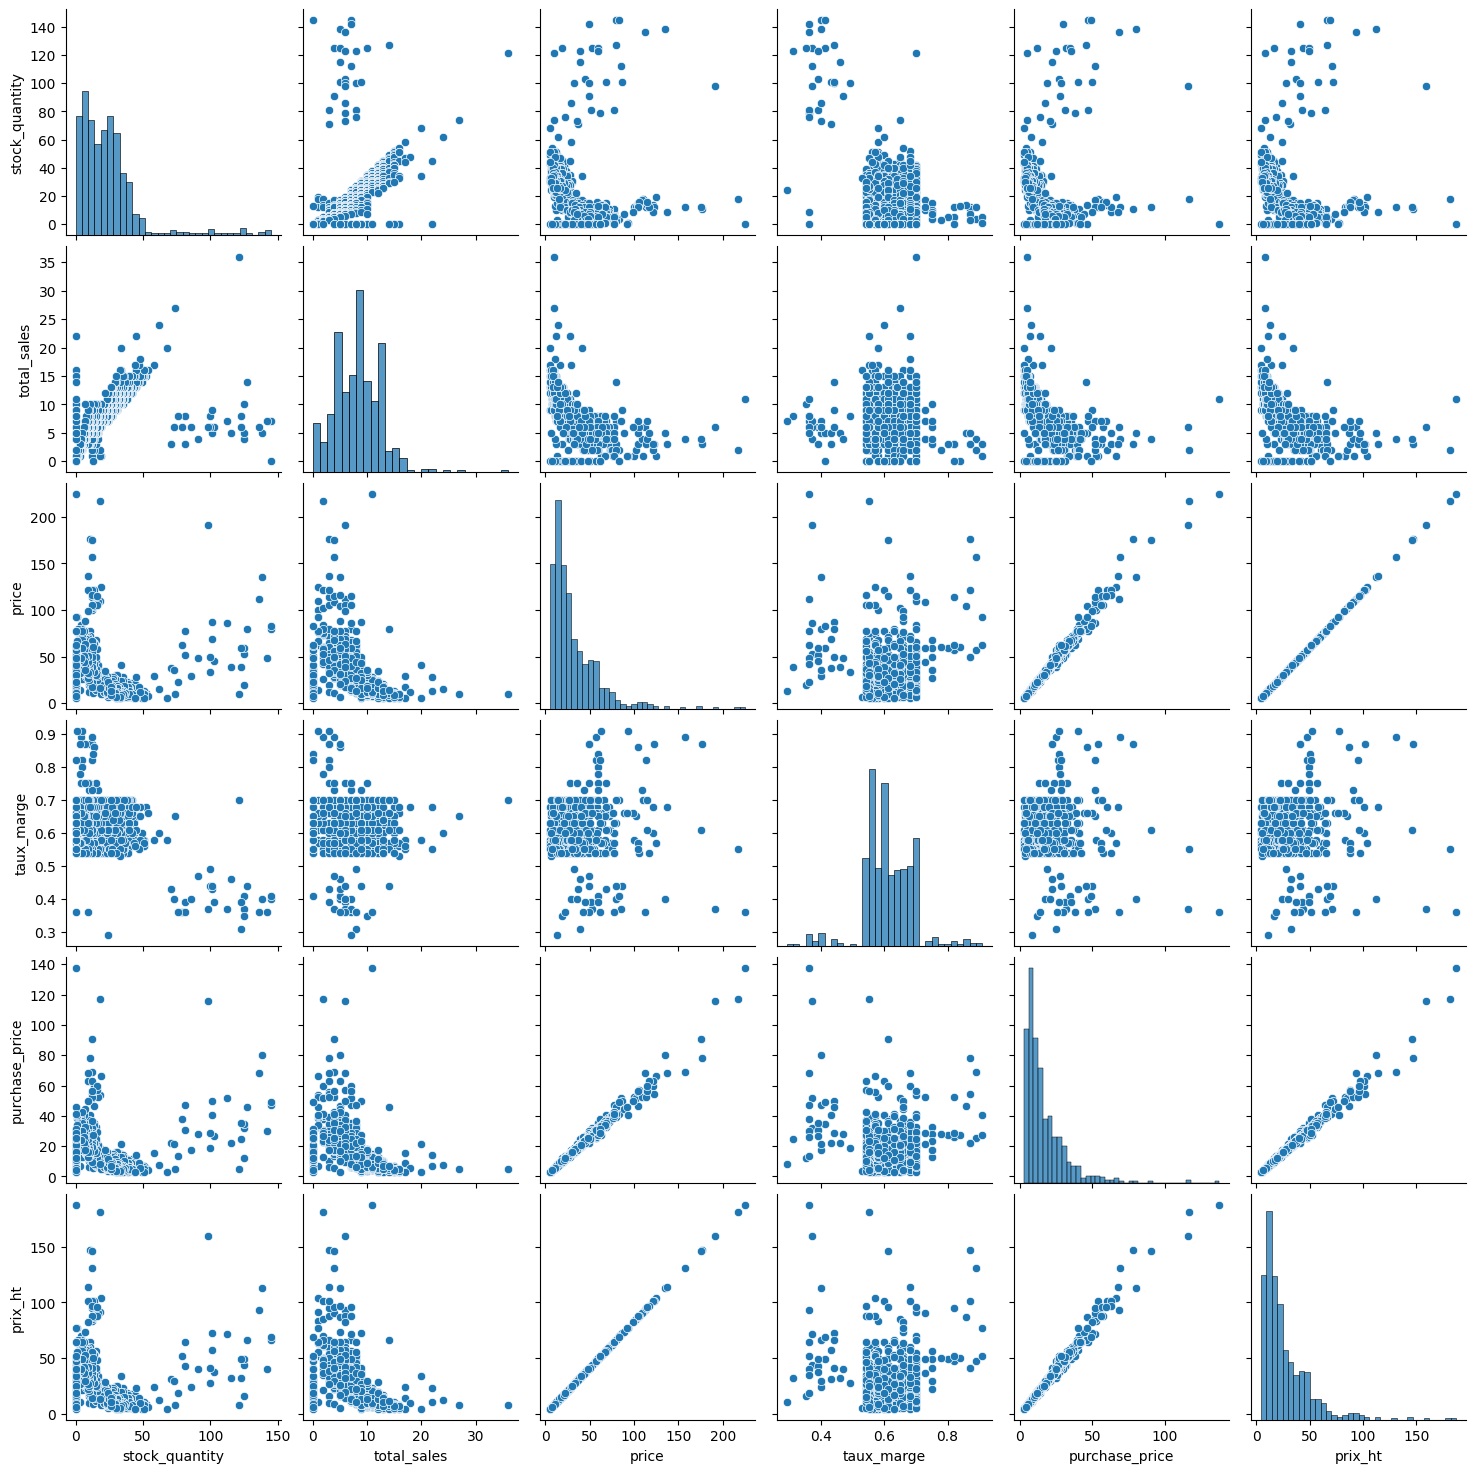

In [ ]:
sns.pairplot(df_taux_positifs[['stock_quantity','total_sales','price','taux_marge','purchase_price','prix_ht']])
plt.show()

In [ ]:
#Que peut-on conclure des corrélations ?
###### Le stock et le total des ventes est la seule combinaison qui présente l'indice d'une éventuelle corrélation

##5.6 - Mise à disposition de la nouvelle table sur un fichier Excel

In [ ]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.

df_final.to_excel('df_final.xlsx', index=False)